# IRP Stage 1 — Initial Baseline Notebook
**MLOps Group Project | Section 1, Group 5**  
*Maria-Irina Popa, Enzo Jerez, Roberto Cummings, Jia Yi Rachel Lee, Thomas Christian Matenco*

---

This notebook implements the **baseline pipeline** for the Inventory Risk Predictor (IRP)

**What this notebook does (top to bottom):**
1. Loads and explores the Kaggle Retail Store Inventory dataset (73,100 rows)
2. Derives the three-class risk labels (Stockout Risk / Overstock Risk / Safe Zone)
3. Performs temporal train/val/test splits to prevent lookahead bias
4. Evaluates the rule-based heuristic baseline
5. Trains and evaluates a Logistic Regression statistical baseline
6. Prints metrics and displays class distributions


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, f1_score, recall_score, precision_score, confusion_matrix, ConfusionMatrixDisplay

# Reproducibility
RANDOM_STATE = 42
print("Libraries loaded ✓")


Libraries loaded ✓


## **1. Data Loading and Data Cleaning**

### 1.1. Load the data

In [2]:
DATA_PATH = "../data/retail_store_inventory.csv"

df_orig = pd.read_csv(DATA_PATH, parse_dates=["Date"])
df_orig = df_orig.sort_values(["Store ID", "Product ID", "Date"]).reset_index(drop=True)

print(f"Shape: {df_orig.shape}")
print(f"Date range: {df_orig['Date'].min().date()} → {df_orig['Date'].max().date()}")
print(f"Missing values: {df_orig.isnull().sum().sum()}")
df_orig.head()


Shape: (73100, 15)
Date range: 2022-01-01 → 2024-01-01
Missing values: 0


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-02,S001,P0001,Groceries,West,116,81,104,92.94,27.95,10,Cloudy,0,30.89,Spring
2,2022-01-03,S001,P0001,Electronics,West,154,5,189,5.36,62.70,20,Rainy,0,58.22,Winter
3,2022-01-04,S001,P0001,Groceries,South,85,58,193,52.87,77.88,15,Cloudy,1,75.99,Winter
4,2022-01-05,S001,P0001,Groceries,South,238,147,37,150.27,28.46,20,Sunny,1,29.40,Winter


In [3]:
df_orig.info()

<class 'pandas.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                73100 non-null  datetime64[us]
 1   Store ID            73100 non-null  str           
 2   Product ID          73100 non-null  str           
 3   Category            73100 non-null  str           
 4   Region              73100 non-null  str           
 5   Inventory Level     73100 non-null  int64         
 6   Units Sold          73100 non-null  int64         
 7   Units Ordered       73100 non-null  int64         
 8   Demand Forecast     73100 non-null  float64       
 9   Price               73100 non-null  float64       
 10  Discount            73100 non-null  int64         
 11  Weather Condition   73100 non-null  str           
 12  Holiday/Promotion   73100 non-null  int64         
 13  Competitor Pricing  73100 non-null  float64       
 14  S

### 1.2. Clean the data

In [4]:
# Create new df to store cleaned data
df = df_orig.copy()


In [5]:
# Check for missing values
print("\n=== MISSING VALUES ===")
null_counts = df.isnull().sum()
null_pct    = df.isnull().mean() * 100
missing = pd.DataFrame({'count': null_counts, 'pct': null_pct})
print(missing)



=== MISSING VALUES ===
                    count  pct
Date                    0  0.0
Store ID                0  0.0
Product ID              0  0.0
Category                0  0.0
Region                  0  0.0
Inventory Level         0  0.0
Units Sold              0  0.0
Units Ordered           0  0.0
Demand Forecast         0  0.0
Price                   0  0.0
Discount                0  0.0
Weather Condition       0  0.0
Holiday/Promotion       0  0.0
Competitor Pricing      0  0.0
Seasonality             0  0.0


In [6]:
# Check for duplicate rows
duplicate_rows = df[df.duplicated(keep=False)]
duplicate_rows

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality


In [7]:
# Extract unique values in categorical variables
for col in df.select_dtypes(include="str").columns:
    n = df[col].nunique()
    vals = df[col].unique()
    print(f"{col}: {n} unique: {vals}")

Store ID: 5 unique: <ArrowStringArray>
['S001', 'S002', 'S003', 'S004', 'S005']
Length: 5, dtype: str
Product ID: 20 unique: <ArrowStringArray>
['P0001', 'P0002', 'P0003', 'P0004', 'P0005', 'P0006', 'P0007', 'P0008',
 'P0009', 'P0010', 'P0011', 'P0012', 'P0013', 'P0014', 'P0015', 'P0016',
 'P0017', 'P0018', 'P0019', 'P0020']
Length: 20, dtype: str
Category: 5 unique: <ArrowStringArray>
['Groceries', 'Electronics', 'Furniture', 'Toys', 'Clothing']
Length: 5, dtype: str
Region: 4 unique: <ArrowStringArray>
['North', 'West', 'South', 'East']
Length: 4, dtype: str
Weather Condition: 4 unique: <ArrowStringArray>
['Rainy', 'Cloudy', 'Sunny', 'Snowy']
Length: 4, dtype: str
Seasonality: 4 unique: <ArrowStringArray>
['Autumn', 'Spring', 'Winter', 'Summer']
Length: 4, dtype: str


In [8]:
# Fix datatypes

# Categorical columns
cat_cols = [
    'Store ID',
    'Product ID', 
    'Category',
    'Region',
    'Weather Condition',
    'Seasonality',
]
df[cat_cols] = df[cat_cols].astype('category')

# Boolean — Holiday/Promotion
df['Holiday/Promotion'] = df['Holiday/Promotion'].astype(bool)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                73100 non-null  datetime64[us]
 1   Store ID            73100 non-null  category      
 2   Product ID          73100 non-null  category      
 3   Category            73100 non-null  category      
 4   Region              73100 non-null  category      
 5   Inventory Level     73100 non-null  int64         
 6   Units Sold          73100 non-null  int64         
 7   Units Ordered       73100 non-null  int64         
 8   Demand Forecast     73100 non-null  float64       
 9   Price               73100 non-null  float64       
 10  Discount            73100 non-null  int64         
 11  Weather Condition   73100 non-null  category      
 12  Holiday/Promotion   73100 non-null  bool          
 13  Competitor Pricing  73100 non-null  float64       
 14  S

## **2. Exploratory Data Analysis (EDA)**

In [9]:
# Overview of key Categorical columns
for col in ["Category", "Region", "Seasonality", "Weather Condition"]:
    print(f"{col}: {df[col].unique().tolist()}")


Category: ['Groceries', 'Electronics', 'Furniture', 'Toys', 'Clothing']
Region: ['North', 'West', 'South', 'East']
Seasonality: ['Autumn', 'Spring', 'Winter', 'Summer']
Weather Condition: ['Rainy', 'Cloudy', 'Sunny', 'Snowy']


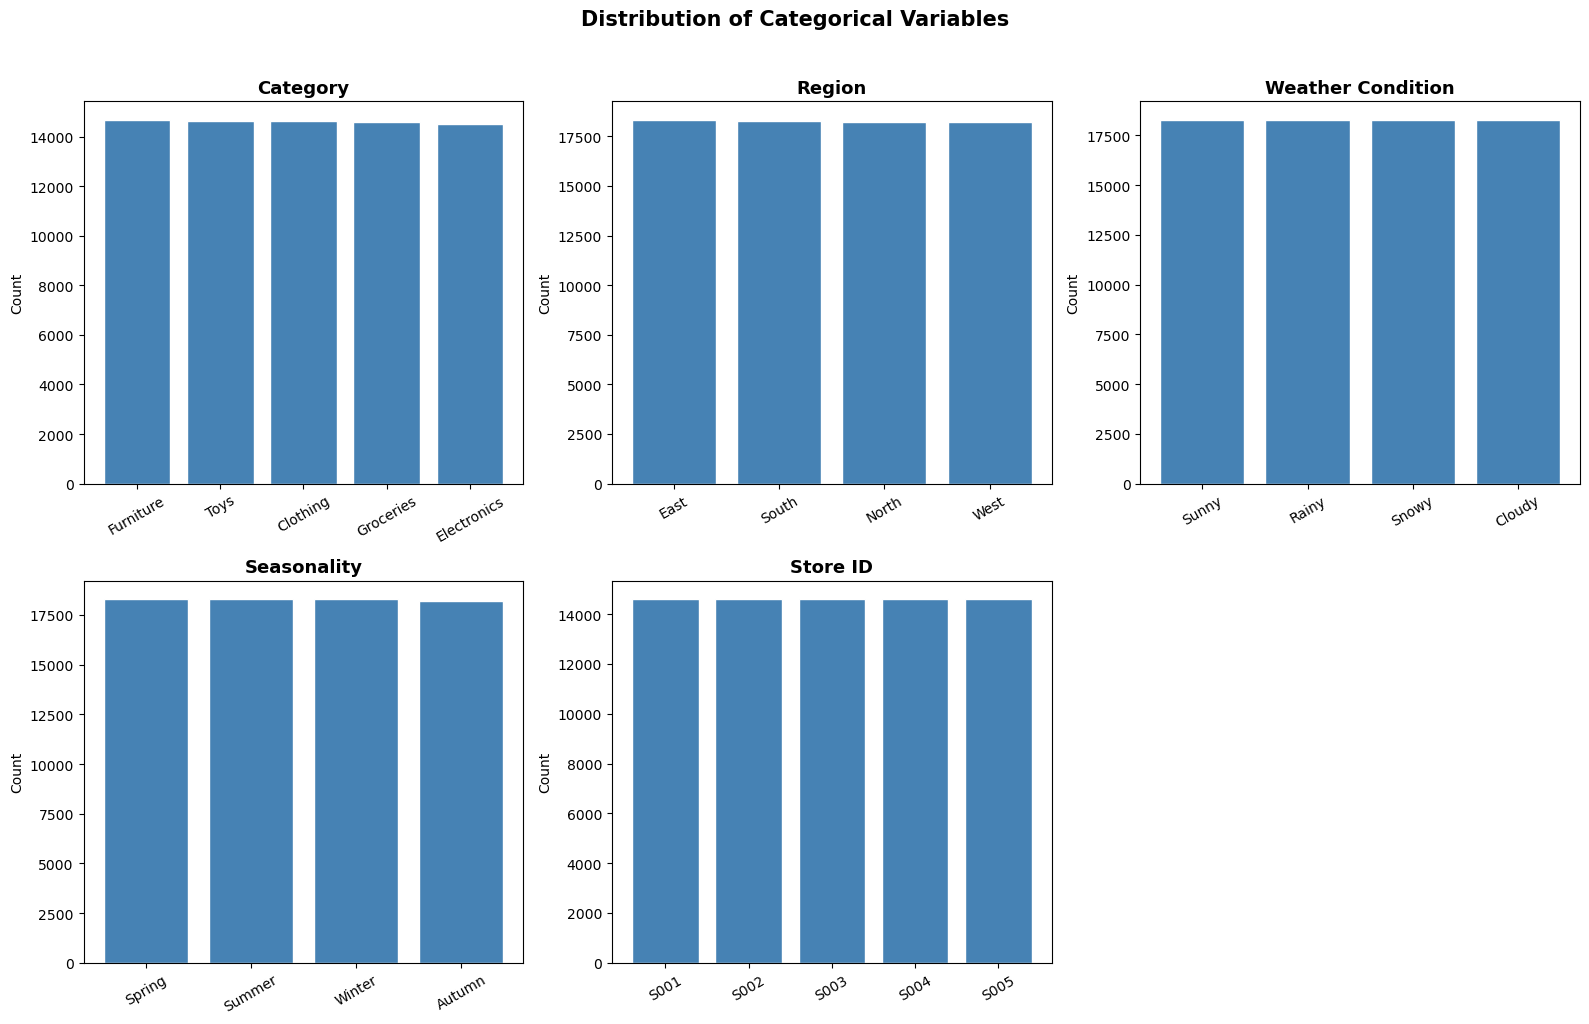

In [10]:
# Plot bar charts for categorical variables
cat_cols = ['Category', 'Region', 'Weather Condition', 'Seasonality', 'Store ID']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    axes[i].bar(counts.index, counts.values, color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=13, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=30)

# Hide the unused 6th subplot
axes[-1].set_visible(False)

plt.suptitle('Distribution of Categorical Variables', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [11]:
# Summary statistics for all numerical columns
df.describe().round(2)

,Date,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Competitor Pricing
count,73100,73100.00,73100.00,73100.00,73100.00,73100.00,73100.00,73100.00
mean,2023-01-01 00:00:00,274.47,136.46,110.00,141.49,55.14,10.01,55.15
min,2022-01-01 00:00:00,50.00,0.00,20.00,-9.99,10.00,0.00,5.03
25%,2022-07-02 00:00:00,162.00,49.00,65.00,53.67,32.65,5.00,32.68
50%,2023-01-01 00:00:00,273.00,107.00,110.00,113.02,55.05,10.00,55.01
75%,2023-07-03 00:00:00,387.00,203.00,155.00,208.05,77.86,15.00,77.82
max,2024-01-01 00:00:00,500.00,499.00,200.00,518.55,100.00,20.00,104.94
std,NaN,129.95,108.92,52.28,109.25,26.02,7.08,26.19


In [12]:
# Summary statistics for key numerical columns
df[["Inventory Level", "Units Sold", "Demand Forecast", "Price", "Competitor Pricing"]].describe().round(2)


,Inventory Level,Units Sold,Demand Forecast,Price,Competitor Pricing
count,73100.00,73100.00,73100.00,73100.00,73100.00
mean,274.47,136.46,141.49,55.14,55.15
std,129.95,108.92,109.25,26.02,26.19
min,50.00,0.00,-9.99,10.00,5.03
25%,162.00,49.00,53.67,32.65,32.68
50%,273.00,107.00,113.02,55.05,55.01
75%,387.00,203.00,208.05,77.86,77.82
max,500.00,499.00,518.55,100.00,104.94


From the summary statistics above, one clear thing that stands out is that the `Demand Forecast` variable has negative values, which would be cleaned and addressed subsequently. 

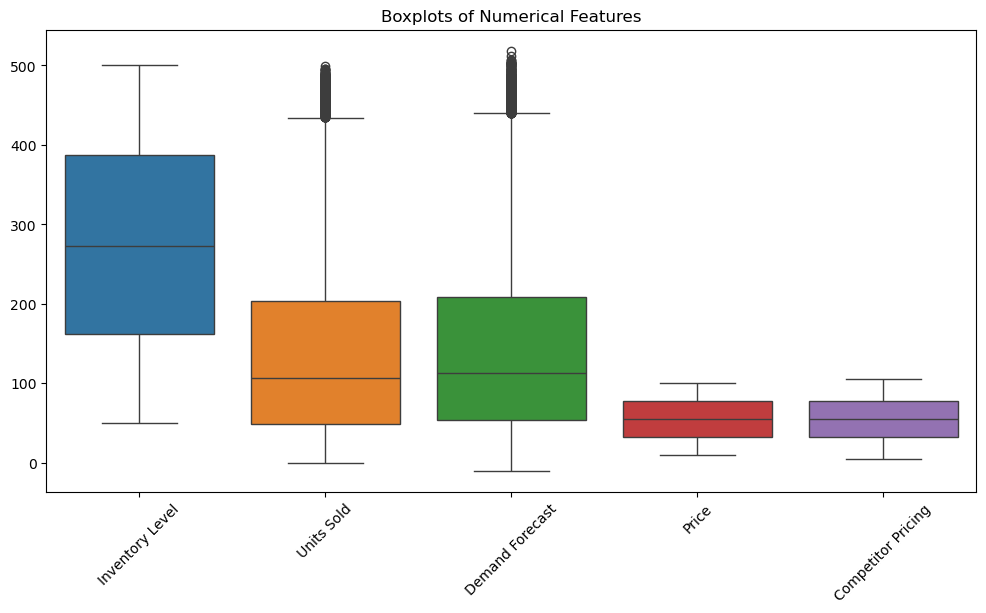

In [13]:
# Plot boxplots for key numerical columns
cols = ["Inventory Level", "Units Sold", "Demand Forecast", "Price", "Competitor Pricing"]

# Create boxplots
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[cols])

plt.title("Boxplots of Numerical Features")
plt.xticks(rotation=45)
plt.show()

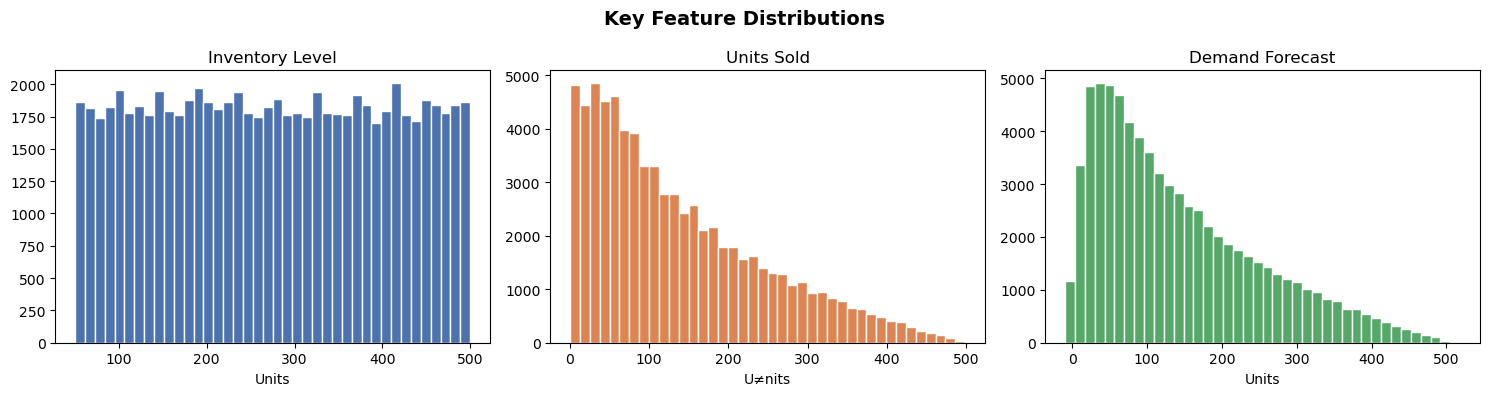

In [14]:
# Distribution plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Key Feature Distributions", fontsize=14, fontweight="bold")


axes[0].hist(df["Inventory Level"], bins=40, color="#4C72B0", edgecolor="white")
axes[0].set_title("Inventory Level")
axes[0].set_xlabel("Units")
axes[1].hist(df["Units Sold"], bins=40, color="#DD8452", edgecolor="white")
axes[1].set_xlabel("U≠nits")
axes[1].set_title("Units Sold")

axes[2].hist(df["Demand Forecast"], bins=40, color="#55A868", edgecolor="white")
axes[2].set_title("Demand Forecast")
axes[2].set_xlabel("Units")

plt.tight_layout()
plt.show()

In [15]:
# Clean demand forecast: clip negatives to 1 to avoid broken comparisons
df["Demand_Forecast_Clean"] = df["Demand Forecast"].clip(lower=1)

In [16]:
# Check data again after cleaning
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Date                   73100 non-null  datetime64[us]
 1   Store ID               73100 non-null  category      
 2   Product ID             73100 non-null  category      
 3   Category               73100 non-null  category      
 4   Region                 73100 non-null  category      
 5   Inventory Level        73100 non-null  int64         
 6   Units Sold             73100 non-null  int64         
 7   Units Ordered          73100 non-null  int64         
 8   Demand Forecast        73100 non-null  float64       
 9   Price                  73100 non-null  float64       
 10  Discount               73100 non-null  int64         
 11  Weather Condition      73100 non-null  category      
 12  Holiday/Promotion      73100 non-null  bool          
 13  Competitor P

## **3. Labelling Strategy**

Labels are derived from existing variables using the framework defined in the checkpoint:

| Label | Condition |
|---|---|
| **Stockout Risk** | `Inventory Level < Demand Forecast × θ_low` |
| **Overstock Risk** | `Inventory Level > Demand Forecast × θ_high` AND low sales velocity |
| **Safe Zone** | Neither condition met |

> When both conditions are met, **Stockout Risk takes precedence** (higher cost implication).  
> Thresholds `θ_low` and `θ_high` are treated as tunable parameters.


The **Inventory-to-Demand ratio** is first calculated to determine an appropriate starting threshold values to set.

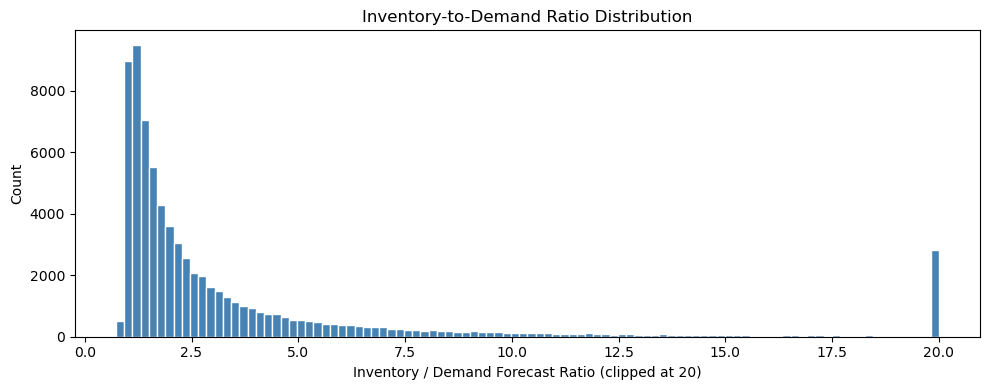


=== Inventory-to-Demand Ratio Percentiles ===
   min: 0.730
   p20: 1.212
   p40: 1.604
   p60: 2.370
   p80: 4.494
   max: 499.000


In [17]:
# Check inventory-to-demand ratio first
df['inv_demand_ratio'] = df['Inventory Level'] / df['Demand_Forecast_Clean']

# Plot distribution of inventory-to-demand ratio
plt.figure(figsize=(10, 4))
plt.hist(df['inv_demand_ratio'].clip(upper=20), bins=100,
         color='steelblue', edgecolor='white')
plt.xlabel('Inventory / Demand Forecast Ratio (clipped at 20)')
plt.ylabel('Count')
plt.title('Inventory-to-Demand Ratio Distribution')
plt.tight_layout()
plt.show()

# Check percentile table in 20% steps
percentiles = [0.00, 0.20, 0.40, 0.60, 0.80, 1.00]
labels      = ['min', 'p20', 'p40', 'p60', 'p80', 'max']
values      = df['inv_demand_ratio'].quantile(percentiles)

print("\n=== Inventory-to-Demand Ratio Percentiles ===")
for label, val in zip(labels, values):
    print(f"  {label:>4}: {val:.3f}")

Based on the output above, the dataset represents a heavily overstocked environment, 
with many stores holding large inventory buffers. Using the percentile distribution 
as a guide, we set the following starting thresholds:

- **θ_low = 1.2** — 20th percentile. Flags Stockout Risk when inventory is less than 20% above forecasted demand, providing early warning before stock runs out.
- **θ_high = 4.5** — 80th percentile. Flags Overstock Risk when inventory exceeds 4.5x forecasted demand, reflecting the actual scale of this dataset.

Additionally, the sales velocity threshold is set at 0.8, to complement twith he theta high threshold to more reliably determine whether there is an overstock risk, where in a typicall business context, the sales demand often come to play as well.

***Note:** These are tunable parameters subject to sensitivity analysis in later stages.*

In [18]:
# Define Tunable thresholds (sensitivity analysis in later stages) ──
THETA_LOW  = 1.2   # Stockout:  Inventory < Demand * THETA_LOW
THETA_HIGH = 4.5   # Overstock: Inventory > Demand * THETA_HIGH
SALES_VELOCITY_THRESHOLD = 0.8  # Overstock also requires low sales movement

In [19]:
# Establish labelling logic
stockout_mask  = df["Inventory Level"] < df["Demand_Forecast_Clean"] * THETA_LOW
overstock_mask = (
    (df["Inventory Level"] > df["Demand_Forecast_Clean"] * THETA_HIGH) &
    (df["Units Sold"] < df["Demand_Forecast_Clean"] * SALES_VELOCITY_THRESHOLD)

)
# Current-day labels (intermediate step)
df["Risk_Label_Current"] = "Safe Zone"
df.loc[overstock_mask, "Risk_Label_Current"] = "Overstock Risk"
df.loc[stockout_mask,  "Risk_Label_Current"] = "Stockout Risk"   # Stockout takes precedence

# t+1 shift: each row now carries tomorrow's risk label
# This makes the model predict FUTURE risk from TODAY's features
df["Risk_Label"] = df.groupby(["Store ID", "Product ID"])["Risk_Label_Current"].shift(-1)

# Drop the last day of each Store+Product series (no future label available)
df = df.dropna(subset=["Risk_Label"]).reset_index(drop=True)

print("Class distribution:")
counts = df["Risk_Label"].value_counts()
pcts   = df["Risk_Label"].value_counts(normalize=True).mul(100).round(1)
for label in counts.index:
    print(f"  {label:<18} {counts[label]:>6,}  ({pcts[label]}%)")

Class distribution:
  Safe Zone          53,630  (73.5%)
  Stockout Risk      14,047  (19.2%)
  Overstock Risk      5,323  (7.3%)


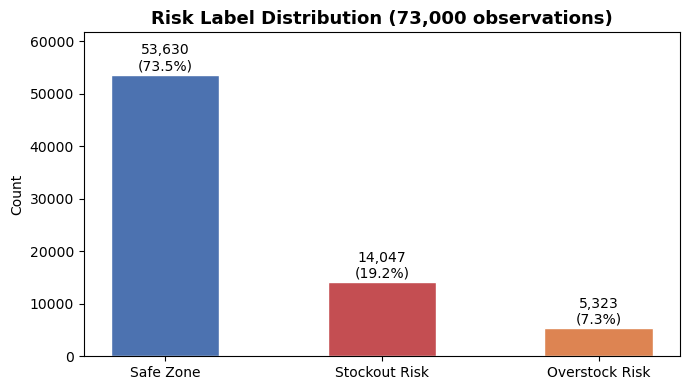


Class imbalance confirmed — Safe Zone dominates (73.5%)
→ Class weighting and SMOTE will be applied in later modelling stages.


In [20]:
# Visualise class distribution
fig, ax = plt.subplots(figsize=(7, 4))
colors = {"Safe Zone": "#4C72B0", "Stockout Risk": "#C44E52", "Overstock Risk": "#DD8452"}
labels = df["Risk_Label"].value_counts().index
values = df["Risk_Label"].value_counts().values

bars = ax.bar(labels, values, color=[colors[l] for l in labels], edgecolor="white", width=0.5)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
            f"{val:,}\n({val/len(df)*100:.1f}%)", ha="center", va="bottom", fontsize=10)

ax.set_title(f"Risk Label Distribution ({len(df):,} observations)", fontsize=13, fontweight="bold")
ax.set_ylabel("Count")
ax.set_ylim(0, max(values) * 1.15)
plt.tight_layout()
plt.show()
print(f"\nClass imbalance confirmed — Safe Zone dominates ({df['Risk_Label'].value_counts(normalize=True)['Safe Zone']*100:.1f}%)")
print("→ Class weighting and SMOTE will be applied in later modelling stages.")


In [21]:
# Risk distribution by Category and Seasonality
print("Risk Labels by Product Category:")
print(pd.crosstab(df["Category"], df["Risk_Label"]))
print()
print("Risk Labels by Region:")
print(pd.crosstab(df["Region"], df["Risk_Label"]))
print()
print("Risk Labels by Seasonality:")
print(pd.crosstab(df["Seasonality"], df["Risk_Label"]))


Risk Labels by Product Category:
Risk_Label   Overstock Risk  Safe Zone  Stockout Risk
Category                                             
Clothing               1015      10781           2816
Electronics            1052      10672           2773
Furniture              1094      10711           2875
Groceries              1053      10771           2769
Toys                   1109      10695           2814

Risk Labels by Region:
Risk_Label  Overstock Risk  Safe Zone  Stockout Risk
Region                                              
East                  1296      13493           3533
North                 1334      13354           3510
South                 1335      13427           3521
West                  1358      13356           3483

Risk Labels by Seasonality:
Risk_Label   Overstock Risk  Safe Zone  Stockout Risk
Seasonality                                          
Autumn                 1303      13333           3536
Spring                 1281      13417           3589
Su

## **4. Temporal Train / Validation / Test Split**



In [22]:
CUTOFF_VAL  = pd.Timestamp("2023-07-01")
CUTOFF_TEST = pd.Timestamp("2023-11-01")

train = df[df["Date"] <  CUTOFF_VAL].copy()
val   = df[(df["Date"] >= CUTOFF_VAL) & (df["Date"] < CUTOFF_TEST)].copy()
test  = df[df["Date"] >= CUTOFF_TEST].copy()

print(f"Train : {len(train):>6,} rows  ({train['Date'].min().date()} → {train['Date'].max().date()})")
print(f"Val   : {len(val):>6,} rows  ({val['Date'].min().date()} → {val['Date'].max().date()})")
print(f"Test  : {len(test):>6,} rows  ({test['Date'].min().date()} → {test['Date'].max().date()})")
print()
print("Val class distribution:")
print(val["Risk_Label"].value_counts())

Train : 54,600 rows  (2022-01-01 → 2023-06-30)
Val   : 12,300 rows  (2023-07-01 → 2023-10-31)
Test  :  6,100 rows  (2023-11-01 → 2023-12-31)

Val class distribution:
Risk_Label
Safe Zone         9094
Stockout Risk     2318
Overstock Risk     888
Name: count, dtype: int64


To prevent **lookahead bias**, splits follow strict chronological order:

| Split | Period | Size |
|---|---|---|
| Train | Jan 2022 – Jun 2023 | ~75% |
| Validation | Jul 2023 – Oct 2023 | ~17% |
| Test | Nov 2023 – Jan 2024 | ~8% (held out) |


## 5. Baseline 1 — Rule-Based Heuristic

Simple threshold rules that replicate the labelling logic, applied directly as predictions.  
This is the **minimum bar** for any ML model to beat.

In [23]:
# Define rule-based prediction function
def rule_based_predict(df_in, theta_low=THETA_LOW, theta_high=THETA_HIGH,
                       sales_vel=SALES_VELOCITY_THRESHOLD):
    preds = pd.Series("Safe Zone", index=df_in.index)
    preds[(df_in["Inventory Level"] > df_in["Demand_Forecast_Clean"] * theta_high) &
          (df_in["Units Sold"] < df_in["Demand_Forecast_Clean"] * sales_vel)] = "Overstock Risk"
    preds[df_in["Inventory Level"] < df_in["Demand_Forecast_Clean"] * theta_low] = "Stockout Risk"
    return preds

Unlike learned models, the rule-based heuristic requires no training. Instead, it applies the thresholds directly to the validation set, making it the natural starting point for comparison.


In [24]:
val_rule_preds = rule_based_predict(val)

In [25]:
rule_f1 = f1_score(val["Risk_Label"], val_rule_preds, average="weighted")

print(f"Rule-based Baseline — Weighted F1: {rule_f1:.4f}")
print()
print(classification_report(val["Risk_Label"], val_rule_preds))


Rule-based Baseline — Weighted F1: 0.5906

                precision    recall  f1-score   support

Overstock Risk       0.08      0.08      0.08       888
     Safe Zone       0.74      0.74      0.74      9094
 Stockout Risk       0.20      0.20      0.20      2318

      accuracy                           0.59     12300
     macro avg       0.34      0.34      0.34     12300
  weighted avg       0.59      0.59      0.59     12300



The rule-based heuristic achieves a weighted F1 of 0.59, establishing the minimum performance bar. As mentioned in the checkpoint report, any ML model must achieve at least a **F1 ≥ 0.64** (5 percentage points above this baseline) to justify the use of ML over simple threshold rules.

Furthermore, the Stockout Recall of 0.20 and Overstock Recall of 0.08 confirm that rule-based thresholds alone are insufficient for reliable risk prediction — the t+1 forward-looking label design requires a model capable of learning temporal patterns, which rules cannot capture.

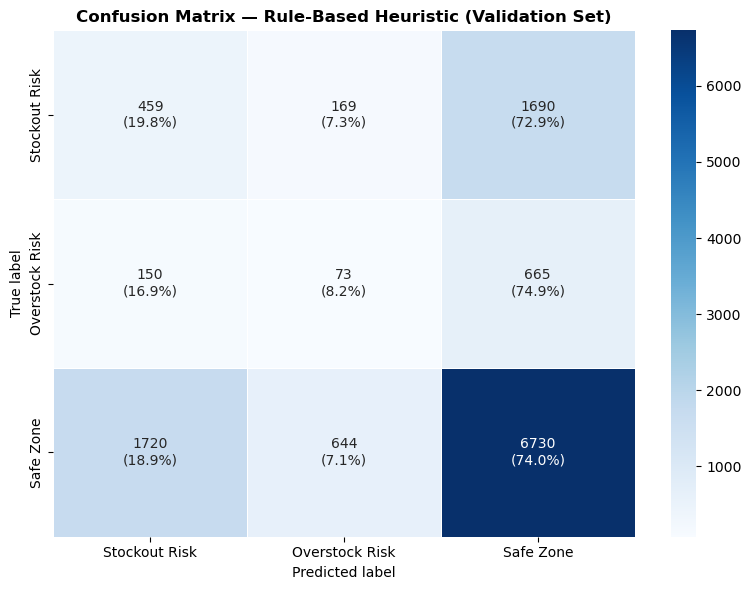

In [26]:
# Confusion matrix — Rule-based
labels_order = ["Stockout Risk", "Overstock Risk", "Safe Zone"]
cm = confusion_matrix(val["Risk_Label"], val_rule_preds, labels=labels_order)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

annot = np.empty_like(cm, dtype=object)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        annot[i, j] = f"{cm[i, j]}\n({cm_pct[i, j]:.1f}%)"

import seaborn as sns
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=annot, fmt="", cmap="Blues",
            xticklabels=labels_order, yticklabels=labels_order,
            linewidths=0.5, ax=ax)
ax.set_title("Confusion Matrix — Rule-Based Heuristic (Validation Set)", 
             fontweight="bold")
ax.set_ylabel("True label")
ax.set_xlabel("Predicted label")
plt.tight_layout()
plt.show()


The confusion matrix also reinforces the narrative — the model is heavily biased toward predicting Safe Zone across all classes, correctly identifying only 19.8% of Stockout cases and 8.2% of Overstock cases. This is structurally expected: static thresholds applied to a forward-looking (t+1) label cannot capture inventory trend dynamics, confirming that a learned model capable of detecting temporal patterns is necessary.

## **6. Baseline 2 — Logistic Regression**

A multinomial logistic regression serves as the **statistical baseline**, assessing linear separability and as a benchmark, before moving to ensemble models in later stages.

In [27]:
# Features encoding
FEATURES = ["Inventory Level", "Units Sold", "Demand Forecast",
            "Price", "Discount", "Competitor Pricing", "Holiday/Promotion"]
CATEGORICAL_COLS = ["Category", "Region", "Weather Condition", "Seasonality"]

for col in CATEGORICAL_COLS:
    le = LabelEncoder()
    le.fit(train[col])
    train[col + "_enc"] = le.transform(train[col])
    val[col + "_enc"]   = le.transform(val[col])
    test[col + "_enc"]  = le.transform(test[col])
    FEATURES.append(col + "_enc")

X_train, y_train = train[FEATURES], train["Risk_Label"]
X_val,   y_val   = val[FEATURES],   val["Risk_Label"]

print(f"Features used: {len(FEATURES)}")
print(FEATURES)

Features used: 11
['Inventory Level', 'Units Sold', 'Demand Forecast', 'Price', 'Discount', 'Competitor Pricing', 'Holiday/Promotion', 'Category_enc', 'Region_enc', 'Weather Condition_enc', 'Seasonality_enc']


As with the rule-based heuristic, the model is evaluated on the validation set to ensure a consistent and fair comparison across both baselines.

In [28]:
# Train Logistic Regression with class balancing
lr = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)
lr.fit(X_train, y_train)

lr_preds = lr.predict(X_val)
lr_f1 = f1_score(y_val, lr_preds, average="weighted")

print(f"Logistic Regression — Weighted F1: {lr_f1:.4f}")
print()
print(classification_report(y_val, lr_preds))

Logistic Regression — Weighted F1: 0.2947

                precision    recall  f1-score   support

Overstock Risk       0.07      0.43      0.12       888
     Safe Zone       0.74      0.21      0.33      9094
 Stockout Risk       0.18      0.35      0.24      2318

      accuracy                           0.25     12300
     macro avg       0.33      0.33      0.23     12300
  weighted avg       0.58      0.25      0.29     12300



Despite a lower weighted F1 (0.29 vs 0.59), the Logistic Regression model meaningfully improves Stockout Recall from 0.20 → 0.35 and Overstock Recall from 0.08 → 0.43. The precision collapse is a known consequence of `class_weight='balanced'` on imbalanced data.

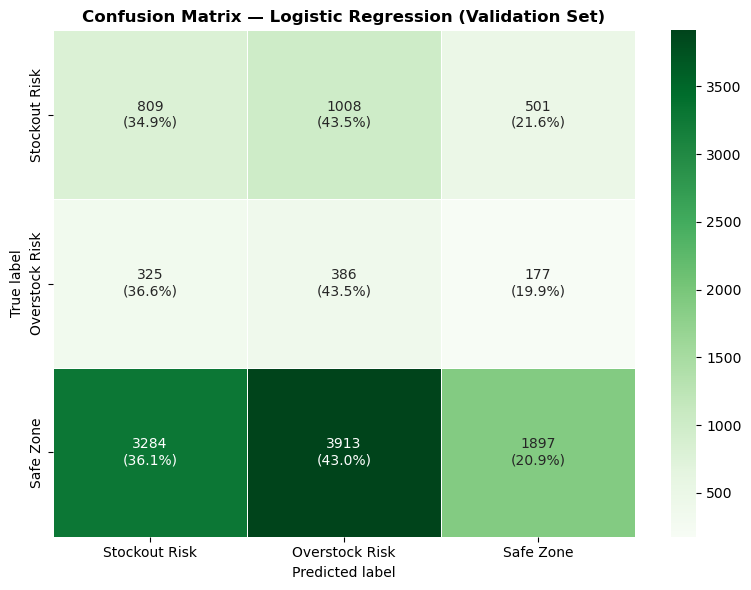

In [29]:
# Confusion matrix — Logistic Regression
labels_order = ["Stockout Risk", "Overstock Risk", "Safe Zone"]
cm_lr = confusion_matrix(y_val, lr_preds, labels=labels_order)
cm_lr_pct = cm_lr.astype(float) / cm_lr.sum(axis=1, keepdims=True) * 100

annot = np.empty_like(cm_lr, dtype=object)
for i in range(cm_lr.shape[0]):
    for j in range(cm_lr.shape[1]):
        annot[i, j] = f"{cm_lr[i, j]}\n({cm_lr_pct[i, j]:.1f}%)"

import seaborn as sns
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_lr, annot=annot, fmt="", cmap="Greens",
            xticklabels=labels_order, yticklabels=labels_order,
            linewidths=0.5, ax=ax)
ax.set_title("Confusion Matrix — Logistic Regression (Validation Set)", fontweight="bold")
ax.set_ylabel("True label")
ax.set_xlabel("Predicted label")
plt.tight_layout()
plt.show()

The confusion matrix confirms the over-prediction pattern — Overstock Risk receives the most predictions (43% of Stockout rows, 43% of Safe Zone rows) despite being the smallest class. The diagonal is weak across all three classes, with Safe Zone correctly identified only 20.9% of the time. This reinforces that LR with class weighting alone is insufficient — Stage 2 feature engineering and Stage 3 ensemble models are needed to improve both recall and precision simultaneously.

## **7. Summary of Baselines**

For meaningful comparison of both baseline on the validation set, the following table was generated. The weighted F1 is the primary metric (as indicated in the Checkpoint report), with Stockout Recall tracked separately given its direct business impact.

In [30]:
# Generate summary table
improvement = (lr_f1 - rule_f1) * 100

print("=" * 55)
print("  BASELINE COMPARISON — VALIDATION SET")
print("=" * 55)
print(f"  Rule-Based Heuristic        Weighted F1: {rule_f1:.4f}")
print(f"  Logistic Regression         Weighted F1: {lr_f1:.4f}")
print(f"  Improvement (LR over rules): {improvement:+.1f} pp")
print("=" * 55)

  BASELINE COMPARISON — VALIDATION SET
  Rule-Based Heuristic        Weighted F1: 0.5906
  Logistic Regression         Weighted F1: 0.2947
  Improvement (LR over rules): -29.6 pp


The weighted F1 comparison alone is misleading — the rule-based model inflates its score by defaulting to Safe Zone, while LR actively learns risk signals at the cost of precision. Stockout Recall improves from 0.20 → 0.35 and Overstock Recall from 0.08 → 0.43, confirming that a learned model captures genuine risk signals. The precision collapse is a known consequence of `class_weight='balanced'` on imbalanced data, motivating the use of ensemble models in **Stage 3**.

## **8. Stage 1 Conclusion**

Stage 1 establishes the baseline pipeline - Both baselines confirm that static rules and simple linear models are insufficient:
- Rule-based model lacks predictive power due to its static, non-temporal nature
- Logistic Regression improves minority class recall but suffers from precision collapse under class weighting

Both results affirm the need for richer feature engineering (Stage 2) and ensemble models with proper imbalance handling (Stage 3) to meet the 5 percentage-points improvement threshold and deliver reliable inventory risk predictions to support business needs.

#### *Notes on Synthetic Data*

The F1 scores in this baseline are inflated by the ***synthetic nature*** of the dataset. Real retail inventory data would have noisier demand signals, more label ambiguity, and lower class separability. These results establish a **methodological baseline** — the pipeline structure, labelling logic, and temporal split discipline — not a performance benchmark. Stages 2 and 3 introduce reconstructed inventory dynamics which partially address this, but the synthetic origin remains a fundamental limitation.


Stages 2 and 3 introduce reconstructed inventory dynamics which partially address this by creating genuine depletion signals, but the synthetic origin of the data remains a fundamental limitation.